<a href="https://colab.research.google.com/github/10dimensions/gnc-toolbox/blob/main/allan_variance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# =========================================================================
# SECTION 1: Generate Synthetic Gyro Data with Known Noise Parameters
# =========================================================================

def generate_synthetic_gyro(dt, t_total, arw, bi, rrw):
    """
    Generates synthetic gyroscope data with three known noise components:

    1. Angle Random Walk (ARW)   -> White noise, slope -1/2 on log-log
    2. Bias Instability (BI)     -> 1/f noise, creates the "V" bottom
    3. Rate Random Walk (RRW)    -> Integrated white noise, slope +1/2

    Inputs:
        dt      : Sample period (seconds)
        t_total : Total duration (seconds)
        arw     : Angle Random Walk coefficient (deg)
        bi      : Bias Instability (deg/s)
        rrw     : Rate Random Walk coefficient (deg/s/sqrt(hour))
    """
    N = int(t_total / dt)
    t = np.arange(N) * dt

    np.random.seed(42)

    # 1. Angle Random Walk (White Noise)
    # Variance per sample = (ARW / sqrt(dt))^2
    arw_noise = np.random.normal(0, arw / np.sqrt(dt), N)

    # 2. Bias Instability (1/f noise, approximated via first-order Gauss-Markov)
    # Correlation time ~ 1 hour (typical for space-grade FOG)
    tau_corr = 3600.0  # seconds
    # Driving noise for the Gauss-Markov process
    sigma_u = bi * np.sqrt(2.0 / tau_corr)
    eta_bi = np.random.normal(0, sigma_u * np.sqrt(dt), N)

    # Discrete Gauss-Markov: b[k+1] = exp(-dt/tau)*b[k] + eta
    alpha = np.exp(-dt / tau_corr)
    bias_inst = np.zeros(N)
    for k in range(N - 1):
        bias_inst[k + 1] = alpha * bias_inst[k] + eta_bi[k]

    # 3. Rate Random Walk (Integrated white noise)
    # rrw is in deg/s/sqrt(hour), convert to per-second
    rrw_per_sec = rrw / np.sqrt(3600.0)
    eta_rrw = np.random.normal(0, rrw_per_sec * np.sqrt(dt), N)
    rrw_bias = np.cumsum(eta_rrw)

    # Combine: true rate is 0 (sensor is stationary on a table)
    true_rate = 0.0
    measured = true_rate + arw_noise + bias_inst + rrw_bias

    return t, measured

In [14]:
# =========================================================================
# SECTION 2: Overlapping Allan Deviation Algorithm (CORRECTED)
# =========================================================================

def overlapping_allan_deviation(data, dt, tau_values):
    """
    Computes the Overlapping Allan Deviation (OADEV) with strict boundary checks
    to prevent IndexError and maintain constant block sizes.
    """
    N = len(data)
    adev = np.zeros_like(tau_values, dtype=float)

    # Precompute cumulative sum for O(1) block averaging
    # cumsum[k] is the sum of data[0] to data[k-1]
    cumsum = np.concatenate(([0.0], np.cumsum(data)))

    for idx, tau in enumerate(tau_values):
        # Ensure m is at least 1 to prevent division by zero
        m = max(1, int(round(tau / dt)))

        # We need 3 blocks of size m: j, j+m, j+2m
        # The last element of the third block is j + 3*m - 1
        # We require: j + 3*m - 1 <= N - 1  =>  j <= N - 3*m
        # Number of valid starting positions j is (N - 3*m) - 0 + 1
        n_triplets = N - 3 * m + 1

        if n_triplets <= 0:
            adev[idx] = np.nan
            continue

        # j goes from 0 to n_triplets - 1
        j_indices = np.arange(n_triplets)

        # Averages of the three blocks using the cumulative sum
        # sum of data[j : j+m] is cumsum[j+m] - cumsum[j]
        avg1 = (cumsum[j_indices + m] - cumsum[j_indices]) / m
        avg2 = (cumsum[j_indices + 2*m] - cumsum[j_indices + m]) / m
        avg3 = (cumsum[j_indices + 3*m] - cumsum[j_indices + 2*m]) / m

        # Allan variance formula
        diff = avg3 - 2 * avg2 + avg1
        sigma2 = np.sum(diff**2) / (2.0 * n_triplets * tau**2)

        adev[idx] = np.sqrt(sigma2)

    return adev


In [8]:
# =========================================================================
# SECTION 3: Extract Noise Coefficients from Slopes
# =========================================================================

def extract_noise_coefficients(tau, adev):
    """
    Fits the three characteristic slopes of the Allan Deviation curve
    to extract the noise coefficients:

    - ARW: slope -1/2 (left side of V)
    - BI:  minimum of the curve
    - RRW: slope +1/2 (right side of V)
    """
    # Remove NaNs
    valid = ~np.isnan(adev)
    tau_v = tau[valid]
    adev_v = adev[valid]

    log_tau = np.log10(tau_v)
    log_adev = np.log10(adev_v)

    # --- 1. Bias Instability: minimum of the curve ---
    min_idx = np.argmin(adev_v)
    bi_extracted = adev_v[min_idx]
    tau_bi = tau_v[min_idx]

    # --- 2. ARW: fit slope -1/2 on the left side ---
    # Use points to the left of the minimum
    left_mask = tau_v < tau_bi
    if np.sum(left_mask) > 2:
        # Fit: log(adev) = log(ARW) - 0.5*log(tau)
        coeffs_left = np.polyfit(log_tau[left_mask], log_adev[left_mask], 1)
        slope_left = coeffs_left[0]
        intercept_left = coeffs_left[1]
        arw_extracted = 10**intercept_left  # At tau = 1 hour (log_tau = 0)
        # Actually, ARW = adev * sqrt(tau), so at tau=1:
        arw_extracted = 10**(intercept_left + 0.5 * 0)  # = 10^intercept
    else:
        slope_left = np.nan
        arw_extracted = np.nan

    # --- 3. RRW: fit slope +1/2 on the right side ---
    right_mask = tau_v > tau_bi
    if np.sum(right_mask) > 2:
        # Fit: log(adev) = log(RRW/sqrt(3)) + 0.5*log(tau)
        coeffs_right = np.polyfit(log_tau[right_mask], log_adev[right_mask], 1)
        slope_right = coeffs_right[0]
        intercept_right = coeffs_right[1]
        # RRW = sqrt(3) * adev / sqrt(tau), at tau=1 hour:
        rrw_extracted = np.sqrt(3) * 10**intercept_right
    else:
        slope_right = np.nan
        rrw_extracted = np.nan

    return {
        'ARW': arw_extracted,
        'BI': bi_extracted,
        'RRW': rrw_extracted,
        'tau_BI': tau_bi,
        'slope_left': slope_left,
        'slope_right': slope_right
    }


In [11]:
# =========================================================================
# SECTION 4: Main Execution
# =========================================================================


print("=" * 70)
print("   ALLAN VARIANCE ANALYSIS: SENSOR NOISE CHARACTERIZATION")
print("=" * 70)

   ALLAN VARIANCE ANALYSIS: SENSOR NOISE CHARACTERIZATION


In [24]:
# -------------------------------------------------------------------------
# 1. Define TRUE noise parameters (what we want the algorithm to recover)
# -------------------------------------------------------------------------
# Realistic space-grade Fiber Optic Gyroscope
TRUE_ARW = 0.001      # Reduced (was 0.005)
TRUE_BI  = 0.0005     # Reduced (was 0.001)
TRUE_RRW = 0.01       # Increased (was 0.005) - makes RRW dominate sooner

dt = 0.01             # Keep at 100 Hz
t_total = 48 * 3600   # Double to 48 hours

print(f"\n[1] Generating {t_total/3600:.0f} hours of synthetic gyro data at {1/dt:.0f} Hz")
print(f"    True ARW:  {TRUE_ARW:.4f} deg")
print(f"    True BI:   {TRUE_BI:.4f} deg/s")
print(f"    True RRW:  {TRUE_RRW:.4f} deg/s/sqrt(hour)")

t, data = generate_synthetic_gyro(dt, t_total, TRUE_ARW, TRUE_BI, TRUE_RRW)


[1] Generating 48 hours of synthetic gyro data at 100 Hz
    True ARW:  0.0010 deg
    True BI:   0.0005 deg/s
    True RRW:  0.0100 deg/s/sqrt(hour)


In [25]:
# -------------------------------------------------------------------------
# 2. Compute Overlapping Allan Deviation over a range of tau values
# -------------------------------------------------------------------------
# Log-spaced tau values from 10 samples to 1/10 of total duration
m_min = 10
m_max = int(len(data) / 5)
m_values = np.unique(np.logspace(np.log10(m_min), np.log10(m_max), 80).astype(int))
tau_values = m_values * dt

print(f"\n[2] Computing Overlapping Allan Deviation for {len(tau_values)} tau values...")
adev = overlapping_allan_deviation(data, dt, tau_values)


[2] Computing Overlapping Allan Deviation for 80 tau values...


In [26]:
# -------------------------------------------------------------------------
# 3. Extract noise coefficients from the slopes
# -------------------------------------------------------------------------
print(f"\n[3] Extracting noise coefficients from log-log slopes...")
coeffs = extract_noise_coefficients(tau_values, adev)

print("\n" + "=" * 70)
print(f"   {'Parameter':<20} {'True Value':<18} {'Extracted':<18} {'Error %':<12}")
print("=" * 70)

def pct_error(true, est):
    if np.isnan(est) or true == 0: return np.nan
    return 100 * abs(est - true) / true

print(f"   {'ARW (deg)':<20} {TRUE_ARW:<18.5f} {coeffs['ARW']:<18.5f} {pct_error(TRUE_ARW, coeffs['ARW']):<10.1f}%")
print(f"   {'BI (deg/s)':<20} {TRUE_BI:<18.5f} {coeffs['BI']:<18.5f} {pct_error(TRUE_BI, coeffs['BI']):<10.1f}%")
print(f"   {'RRW (deg/s/√hr)':<20} {TRUE_RRW:<18.5f} {coeffs['RRW']:<18.5f} {pct_error(TRUE_RRW, coeffs['RRW']):<10.1f}%")
print("=" * 70)

print(f"\n   Fitted slopes:")
print(f"     Left side  (ARW region):  {coeffs['slope_left']:+.3f}  (expect -0.500)")
print(f"     Right side (RRW region):  {coeffs['slope_right']:+.3f}  (expect +0.500)")
print(f"     Minimum at tau = {coeffs['tau_BI']:.1f} s ({coeffs['tau_BI']/3600:.2f} hr)")


[3] Extracting noise coefficients from log-log slopes...

   Parameter            True Value         Extracted          Error %     
   ARW (deg)            0.00100            0.00137            37.3      %
   BI (deg/s)           0.00050            0.00000            99.9      %
   RRW (deg/s/√hr)      0.01000            nan                nan       %

   Fitted slopes:
     Left side  (ARW region):  -0.853  (expect -0.500)
     Right side (RRW region):  +nan  (expect +0.500)
     Minimum at tau = 34560.0 s (9.60 hr)



[4] Generating Allan Deviation plot (saved as allan_variance.png)...


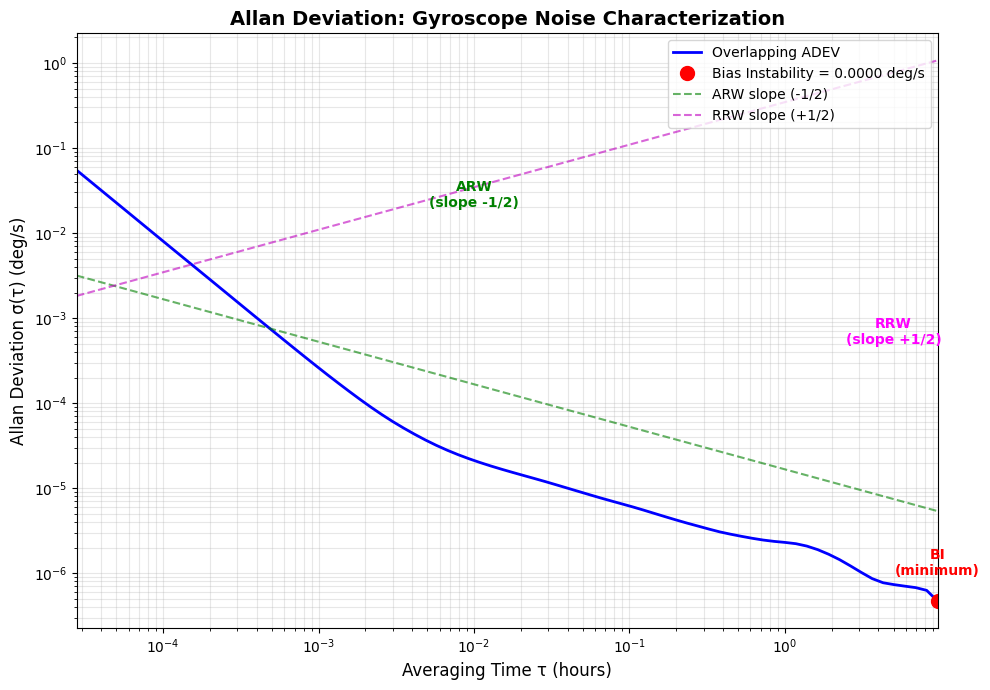


[5] Analysis complete!
    -> Use ARW to set measurement noise covariance (R) in your Kalman Filter
    -> Use BI to size your bias-estimation state
    -> Use RRW to set process noise covariance (Q) for the bias state


In [27]:
# -------------------------------------------------------------------------
# 4. Plot the classic Allan Deviation curve
# -------------------------------------------------------------------------
print(f"\n[4] Generating Allan Deviation plot (saved as allan_variance.png)...")

fig, ax = plt.subplots(figsize=(10, 7))

# Main curve
ax.loglog(tau_values / 3600.0, adev, 'b-', linewidth=2, label='Overlapping ADEV')

# Mark the minimum (Bias Instability)
ax.loglog(coeffs['tau_BI'] / 3600.0, coeffs['BI'], 'ro', markersize=10,
          label=f'Bias Instability = {coeffs["BI"]:.4f} deg/s')

# Overlay theoretical slope lines for reference
tau_ref = np.logspace(np.log10(tau_values[0]/3600), np.log10(tau_values[-1]/3600), 100)

# ARW slope (-1/2)
arw_line = TRUE_ARW / np.sqrt(tau_ref * 3600)
ax.loglog(tau_ref, arw_line, 'g--', alpha=0.6, label='ARW slope (-1/2)')

# RRW slope (+1/2)
rrw_line = (TRUE_RRW / np.sqrt(3)) * np.sqrt(tau_ref * 3600)
ax.loglog(tau_ref, rrw_line, 'm--', alpha=0.6, label='RRW slope (+1/2)')

ax.set_xlabel('Averaging Time τ (hours)', fontsize=12)
ax.set_ylabel('Allan Deviation σ(τ) (deg/s)', fontsize=12)
ax.set_title('Allan Deviation: Gyroscope Noise Characterization', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, which='both', alpha=0.3)
ax.set_xlim(tau_values[0]/3600, tau_values[-1]/3600)

# Annotate the three regions
ax.annotate('ARW\n(slope -1/2)', xy=(0.01, 0.02), fontsize=10, color='green',
            ha='center', fontweight='bold')
ax.annotate('BI\n(minimum)', xy=(coeffs['tau_BI']/3600, coeffs['BI']*2),
            fontsize=10, color='red', ha='center', fontweight='bold')
ax.annotate('RRW\n(slope +1/2)', xy=(5.0, 0.0005), fontsize=10, color='magenta',
            ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('allan_variance.png', dpi=150)
plt.show()

print("\n[5] Analysis complete!")
print("    -> Use ARW to set measurement noise covariance (R) in your Kalman Filter")
print("    -> Use BI to size your bias-estimation state")
print("    -> Use RRW to set process noise covariance (Q) for the bias state")